# Loss Visualization
Notebook này giúp visualize và so sánh Training Loss và Validation Loss một cách linh hoạt từ các checkpoint đã huấn luyện.
Bạn có thể thay thế các đường dẫn checkpoint bên dưới để so sánh biểu đồ loss của chúng với nhau.

In [1]:
import json
import matplotlib.pyplot as plt
import os

def extract_loss_from_state(checkpoint_dir):
    state_file = os.path.join(checkpoint_dir, "trainer_state.json")
    if not os.path.exists(state_file):
        print(f"Không tìm thấy file: {state_file}")
        return {'train': ([], []), 'eval': ([], [])}

    with open(state_file, "r", encoding="utf-8") as f:
        data = json.load(f)

    log_history = data.get("log_history", [])
    
    train_steps = []
    train_loss = []
    eval_steps = []
    eval_loss = []

    for log in log_history:
        if "loss" in log and "step" in log:
            train_steps.append(log["step"])
            train_loss.append(log["loss"])
        elif "eval_loss" in log and "step" in log:
            eval_steps.append(log["step"])
            eval_loss.append(log["eval_loss"])
            
    return {'train': (train_steps, train_loss), 'eval': (eval_steps, eval_loss)}

In [2]:
def plot_losses(checkpoint_dirs, title="Training and Validation Loss Comparison"):
    plt.figure(figsize=(12, 7))
    
    colors = ['blue', 'green', 'red', 'purple', 'orange', 'cyan', 'brown', 'pink']
    
    for idx, cp_dir in enumerate(checkpoint_dirs):
        print(f"Đang đọc dữ liệu từ: {cp_dir}")
        losses = extract_loss_from_state(cp_dir)
        
        # Tạo tên hiển thị ngắn gọn
        cp_name = os.path.basename(os.path.normpath(cp_dir))
        if cp_name.startswith('checkpoint'):
            parent_dir = os.path.basename(os.path.dirname(os.path.normpath(cp_dir)))
            cp_name = f"{parent_dir} ({cp_name})"
                
        train_steps, train_loss = losses['train']
        eval_steps, eval_loss = losses['eval']
        
        c = colors[idx % len(colors)]
        
        if train_steps:
            plt.plot(train_steps, train_loss, label=f"{cp_name} - Train", color=c, linestyle='-', marker='o', markersize=3, alpha=0.7)
        if eval_steps:
            plt.plot(eval_steps, eval_loss, label=f"{cp_name} - Validation", color=c, linestyle='--', marker='x', markersize=5, alpha=0.9)

    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Steps", fontsize=12)
    plt.ylabel("Loss", fontsize=12)
    plt.legend(loc='upper right', bbox_to_anchor=(1.35, 1))
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()

### Khai báo các thư mục checkpoint cần so sánh
Sửa lại danh sách `checkpoints_to_compare` bên dưới để trỏ tới các thư mục bạn muốn trực quan hóa. Bạn có thể thêm nhiều thư mục checkpoint cùng lúc.

Đang đọc dữ liệu từ: ../models/qwen25-3b-v1/checkpoint-850


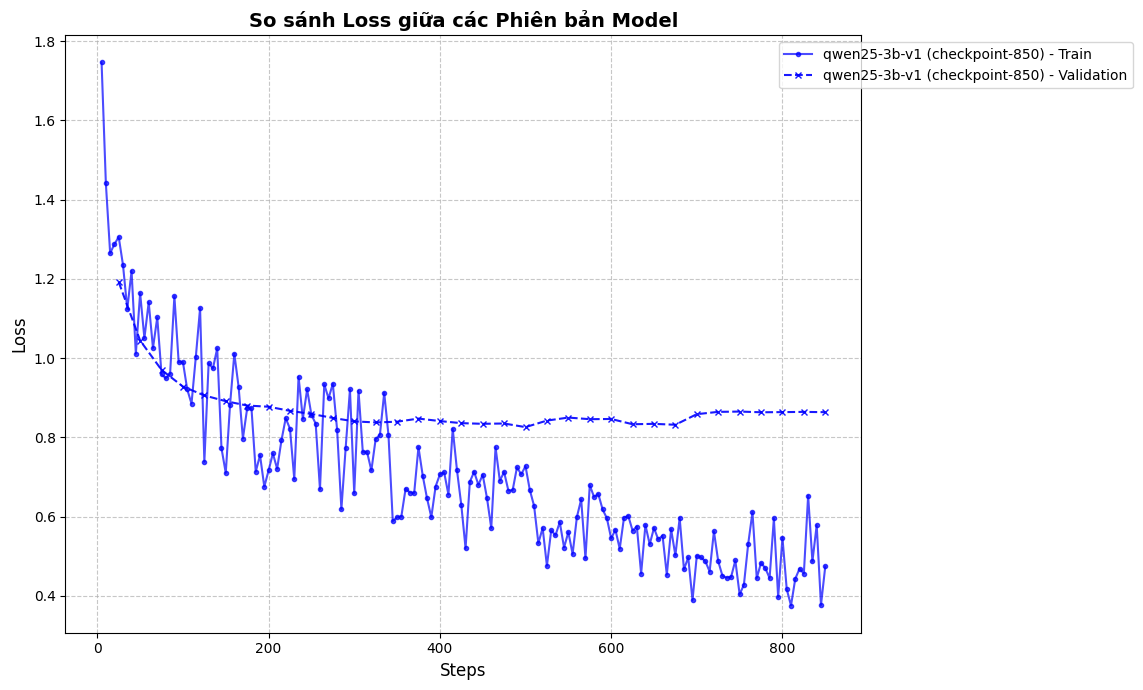

In [4]:
# Liệt kê các thư mục checkpoint bạn muốn so sánh (đường dẫn tương đối từ thư mục notebooks ra thư mục models)
checkpoints_to_compare = [
    "../models/qwen25-3b-v1/checkpoint-850"
]

plot_losses(checkpoints_to_compare, title="So sánh Loss giữa các Phiên bản Model")